In [24]:
#libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [25]:
#reading dataset
df = pd.read_csv("covertype\covtype.data.gz")
print(df.shape)
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\tragh\AppData\Local\Temp\ipykernel_32360\1534560227.py:2: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv("covertype\covtype.data.gz")


(581011, 55)


,2596,51,3,258,0,510,221,232,148,6279,...,0.34,0.35,0.36,0.37,0.38,0.39,0.40,0.41,0.42,5
0,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
1,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
2,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
3,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
4,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2


In [26]:
#labeling stuff 
columns = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

columns += [f"Wilderness_Area{i}" for i in range(1, 5)]
columns += [f"Soil_Type{i}" for i in range(1, 41)]
columns += ["Cover_Type"]

df.columns = columns
print(df.columns.tolist())

['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']


In [27]:
#separating features and target variable
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

#check 
print(X.shape)  # (581012, 54)
print(y.shape)  # (581012,)
df.isnull().sum().sum()

#class separation
y.value_counts()

(581011, 54)
(581011,)


Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9492
4      2747
Name: count, dtype: int64

In [28]:
#Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3,  # ~66.7% of the 30% → becomes 20% total
    random_state=42,
    stratify=y_temp
)

In [29]:
#tuning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

for c in [0.1]:
    model = LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        C=c,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)

    print("C =", c)
    print("Balanced Acc:", balanced_accuracy_score(y_val, preds))

C = 0.1
Balanced Acc: 0.7081754678969672


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)


model.fit(X_train_scaled, y_train)


balanced_model = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [31]:
#Predictions 
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score

# =========================
# REGULAR LOGISTIC MODEL
# =========================

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

# Accuracies
print("=== Regular Logistic Regression ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

# Report
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


# =========================
# BALANCED LOGISTIC MODEL
# =========================

# Predictions
y_train_pred_bal = balanced_model.predict(X_train_scaled)
y_val_pred_bal = balanced_model.predict(X_val_scaled)
y_test_pred_bal = balanced_model.predict(X_test_scaled)

# Accuracies
print("\n=== Balanced Logistic Regression ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_bal):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred_bal):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_bal):.4f}")

# Balanced accuracy (important for imbalance)
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test, y_test_pred_bal):.4f}")

# Report
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred_bal))

=== Regular Logistic Regression ===
Train Accuracy: 0.7246
Validation Accuracy: 0.7243
Test Accuracy: 0.7246

Test Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.70      0.71     42368
           2       0.75      0.80      0.77     56661
           3       0.67      0.80      0.73      7151
           4       0.63      0.42      0.51       549
           5       0.20      0.01      0.01      1899
           6       0.49      0.27      0.35      3473
           7       0.74      0.57      0.64      4102

    accuracy                           0.72    116203
   macro avg       0.60      0.51      0.53    116203
weighted avg       0.71      0.72      0.71    116203


=== Balanced Logistic Regression ===
Train Accuracy: 0.5986
Validation Accuracy: 0.6005
Test Accuracy: 0.5993
Balanced Accuracy (Test): 0.7062

Test Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.66    

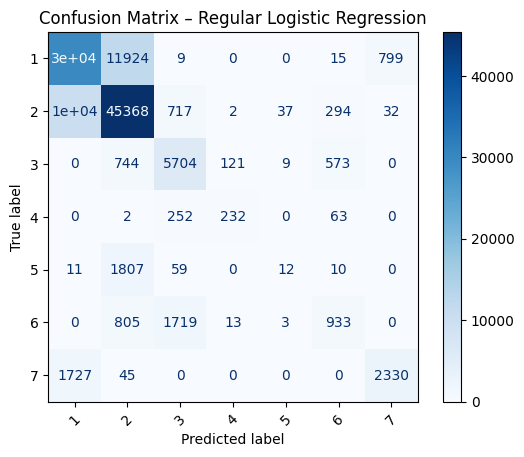

In [33]:
#Matrices
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = [1,2,3,4,5,6,7]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45
)
plt.title("Confusion Matrix – Regular Logistic Regression")
plt.show()

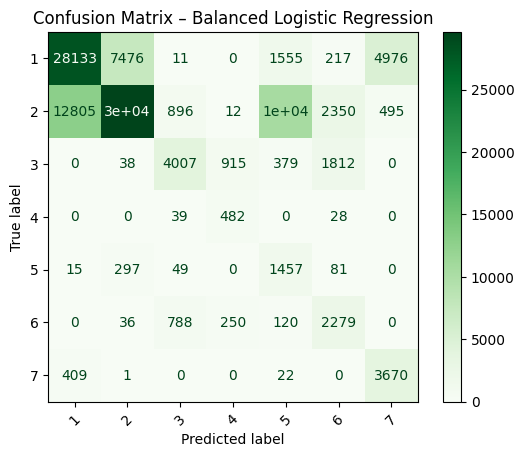

In [34]:
labels = [1,2,3,4,5,6,7]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_bal,
    display_labels=labels,
    cmap="Greens",
    xticks_rotation=45
)
plt.title("Confusion Matrix – Balanced Logistic Regression")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

models = ["Regular Logistic", "Balanced Logistic"]
accuracy = [0.7246, 0.5997] 
plt.figure()
plt.bar(models, accuracy)
plt.title("Logistic Regression Model Comparison (Accuracy)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()